# NB4X: New Wind Scheme diagrams

In [11]:
nb_id = "4x"

In [12]:
from pathlib import Path
from functools import partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

import astropy.units as u
import astropy.constants as ct
from astropy.cosmology import WMAP9 as cosmo
from scipy.interpolate import interp1d

from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

import mesa_reader as mr

import sys
sys.path.append('..')
from src.binary import eggleton_rl1_radius, a_from_p, marchant_l2_radius
from src.util import DATA_DIR, MESA_DATA_DIR, build_logbump35_cmap, savefig_base
from src.constants import Z_SUN
FIGURE_FOLDER = Path(f'../figures/nb{nb_id}')
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)

plt.style.use('./plotstyle.mplstyle')
pd.set_option('display.max_columns', None)

In [13]:
def savefig(fig, fname):
    savefig_base(fig, fname, nb_id, FIGURE_FOLDER)

In [14]:
# OVERWRITE RCPARAMS
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 20,
    'axes.titlesize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 14,
    'figure.titlesize': 22,
    'font.family': 'serif',
    'text.usetex': False  # Set to True if you have a local LaTeX distribution
})

## Wind recipe definitions

In [15]:
def edd_gamma(x, l, m):
    return 10**-4.813 * (1+x) * l/m

def vink2001_w(l, m, teff, z):
    teff_jump = 61.2 + 2.59*(-13.636+0.889*np.log10(z/Z_SUN))
    dteff_jump = 100
    
    if teff > 27.5e3:
        a = 1
    elif teff < 22.5e3:
        a = 0
    else:
        if teff > teff_jump+dteff_jump:
            a = 1
        elif teff < teff_jump-dteff_jump:
            a = 0
        else:
            a = (teff-(teff_jump-dteff_jump))/(2*dteff_jump)
    
    if a > 0:
        vinf_div_vesc = 2.6*(z/Z_SUN)**0.13
        log_mdot = (-6.697
                    +2.194*np.log10(l/1e5)
                    -1.313*np.log10(m/30)
                    -1.226*np.log10(vinf_div_vesc/2)
                    +0.933*np.log10(teff/4e4)
                    -10.92*np.log10(teff/4e4)**2
                    +0.85*np.log10(z/Z_SUN))
        mdot1 = 10.**log_mdot
    else:
        mdot1 = 0
    
    if a < 1:
        vinf_div_vesc = 1.3*(z/Z_SUN)**0.13
        log_mdot = (-6.688
                    +2.210*np.log10(l/1e5)
                    -1.339*np.log10(m/30)
                    -1.601*np.log10(vinf_div_vesc/2)
                    +1.07*np.log10(teff/4e4)
                    +0.85*np.log10(z/Z_SUN))
        mdot2 = 10.**log_mdot
    else:
        mdot2 = 0

    w = a*mdot1 + (1-a)*mdot2
    return w

def krticka2024_w(l, teff, z):
    a = -13.82
    b = 1.52
    c = 3.84
    t1 = 14.16e3
    t2 = 37.9e3
    dt1 = 3.58e3
    dt2 = 56.5e3
    alpha = 0.358
    beta = -0.11
    delta = 0.73
    log_z_div_z_sun = np.log10(z/Z_SUN)
    
    log_lin_comp = (a
                    + alpha * log_z_div_z_sun
                    + (b + beta * log_z_div_z_sun) * np.log10(l/1e6))
    gauss_mix_comp = ((1 + delta * log_z_div_z_sun) * np.exp(-(teff-t1)**2/dt1**2)
                      + c * np.exp(-(teff-t2)**2/dt2**2))
    log_mdot = log_lin_comp - a * np.log10(gauss_mix_comp)
    w = 10.**log_mdot
    return w

def bjorklund2023_w(l, m, teff, z, x):
    g_e = edd_gamma(x, l, m)
    meff = (1-g_e)*m
    log_mdot = (-5.52
                +2.39*np.log10(l/1e6)
                -1.48*np.log10(meff/45)
                +2.12*np.log10(teff/4.5e4)
                +(0.75
                  -1.87*np.log10(teff/4.5e4)) * np.log10(z/Z_SUN))
    w = 10.**log_mdot 
    return w

def sabhahit2023_switch_g(z):
    l = sabhahit2023_switch_l(z)
    m = sabhahit2023_switch_m(z)
    return 2.5e-5 * l/m

def sabhahit2023_switch_l(z):
    return 10.**2.36 * z**-1.91

def sabhahit2023_switch_m(z):
    return 0.0615 * z**-1.574 + 18.1

def vink2011_w(l, m, z):
    logmdot_switch = -1.86*np.log10(z) - 8.9
    l_switch = sabhahit2023_switch_l(z)
    m_switch = sabhahit2023_switch_m(z)
    w = 10.**logmdot_switch * (l/l_switch)**4.77 * (m/m_switch)**-3.99
    return w

def sabhahit2023_w(l, m, teff, z, x):
    g_e = edd_gamma(x, l, m)
    g_e_switch = sabhahit2023_switch_g(z)
    dg_e = 0.01
    
    if g_e > g_e_switch+dg_e:
        a = 1
    elif g_e < g_e_switch-dg_e:
        a = 0
    else:
        a = (g_e-(g_e_switch-dg_e))/(2*dg_e) 
    
    if a > 0:
        w1 = vink2011_w(l, m, z)
    else:
        w1 = 0
    
    if a < 1:
        w2 = bjorklund2023_w(l, m, teff, z, x)
    else:
        w2 = 0
        
    w = a*w1 + (1-a)*w2
    return w
sabhahit2023_w = np.vectorize(sabhahit2023_w)

def vink2017_w(l, z):
    log_mdot = -13.3 + 1.36*np.log10(l) + 0.61*np.log10(z/Z_SUN)
    w = 10.**log_mdot
    return w

@np.vectorize
def sander2023_w(l, t, z):
    logz = np.log10(z/Z_SUN)
    alpha = 0.32 * logz + 1.4
    l0 = 10.**(-0.87*logz + 5.06)
    mdot10 = 10.**(-0.75*logz - 4.06)
    
    if l <= l0:
        log_power_term = 0
    else:
        log_power_term = np.log10(l/l0) ** alpha
    w = mdot10 * log_power_term * (l/(10*l0))**0.75
    
    if t > 1e5 and l > l0:
        log_w = np.log10(w) - 6*np.log10(t/1.41e5)
        w = 10.**log_w
    return w

def winds(l, m, teff, z, x, y):
    x0 = 0.6
    dx = 0.3
    
    g_e = edd_gamma(x, l, m)
    g_switch = sabhahit2023_switch_g(z)
    d_gswitch = 0.01
    
    #MS or WR winds
    if x > x0:
        y_a = 0
    elif x < x0-dx:
        y_a = 1
    else:
        y_a = (x0-x)/(dx)
    #thick or thin MS winds
    if g_e < g_switch - d_gswitch:
        ms_a = 0
    elif g_e > g_switch + d_gswitch:
        ms_a = 1
    else:
        ms_a = (g_e-(g_switch-d_gswitch))/(2*d_gswitch)
        
    bjorklund2023_winds = bjorklund2023_w(l, m, teff, z, x)
    krticka2024_winds = krticka2024_w(l, teff, z)
    vink2011_winds = vink2011_w(l, m, z)
    vink2017_winds = vink2017_w(l, z)
    sander2023_winds = sander2023_w(l, m, teff, z, x)
    
    w = y_a*max(vink2017_winds, sander2023_winds) + (1-y_a) * (ms_a*vink2011_winds + (1-ms_a)*min(bjorklund2023_winds, krticka2024_winds))
    return w
    

In [16]:
def which_wind(l, m, teff, z, x, x0=0.6, dx=0.3):    
    g_e = edd_gamma(x, l, m)
    g_switch = sabhahit2023_switch_g(z)
    d_gswitch = 1e-10
    
    v17_w = vink2017_w(l, z)
    s23_w = sander2023_w(l, teff, z)
    v11_w = vink2011_w(l, m, z)
    b23_w = bjorklund2023_w(l, m, teff, z, x)
    k24_w = krticka2024_w(l, teff, z)

    # Formal names matching regime_map
    V17 = 'Vink (2017)'
    S23 = 'Sander et al. (2023)'
    V11 = 'Vink et al. (2011)'
    B23 = 'Björklund et al. (2023)'
    K24 = 'Krtička et al. (2024)'

    # Helper to determine the winner between Bjorklund and Krticka
    def get_ms_thin_winner():
        return B23 if b23_w < k24_w else K24

    # MS or WR winds (Transition based on x)
    if x > x0:
        y_a = 0
    elif x < x0 - dx:
        y_a = 1
    else:
        y_a = (x0 - x) / dx
        
    # Thick or thin MS winds (Transition based on gamma)
    if g_e < g_switch - d_gswitch:
        ms_a = 0
    elif g_e > g_switch + d_gswitch:
        ms_a = 1
    else:
        ms_a = (g_e - (g_switch - d_gswitch)) / (2 * d_gswitch)
        
    if y_a > 0:
        winner = V17 if v17_w > s23_w else S23
        # Neighbor logic: if we go down to Y=0, we follow MS logic
        if ms_a > 0:
            neighbor = V11 if v11_w > min(b23_w, k24_w) else get_ms_thin_winner()
        else:
            neighbor = get_ms_thin_winner()
        return winner, y_a, neighbor
    else:
        # We are on the MS branch
        if ms_a > 0:
            winner = V11 #if v11_w > min(b23_w, k24_w) else get_ms_thin_winner()
            neighbor = get_ms_thin_winner()
            return winner, ms_a, neighbor
        else:
            # Thin wind regime
            winner = get_ms_thin_winner()
            return winner, 0, winner


In [17]:
L = 10**6.1
Z = 0.2*Z_SUN
M = 60
x0 = 0.6
dx = 0.3

y0 = 1 - x0 
dy = dx

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


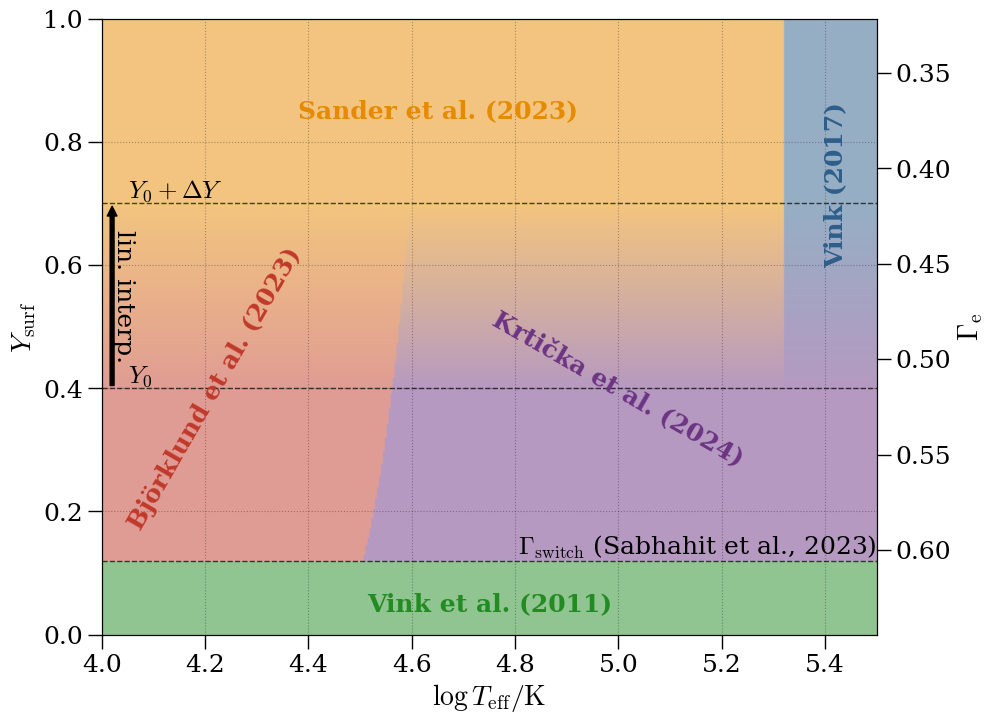

In [ ]:
logteff_range = np.linspace(4, 5.5, 400)
y_range = np.linspace(0, 1, 400)
LT_mesh, Y_mesh = np.meshgrid(logteff_range, y_range)

regime_map = {
    'Vink (2017)': 0, 
    'Sander et al. (2023)': 1, 
    'Vink et al. (2011)': 2, 
    'Björklund et al. (2023)': 3, 
    'Krtička et al. (2024)': 4
}

regimes_to_blend = ["Sander et al. (2023)", "Vink (2017)"]

# Base colors
hex_colors = [
    '#2E5E8A', # Steel Blue (Vink 2017)
    '#E68A00', # Rich Amber (Sander 2023)
    '#228B22', # Forest Green (Vink 2011)
    '#C0392B', # Soft Crimson (Bjorklund 2023)
    '#6C3483'  # Muted Plum (Krticka 2024)
]
hex_colors_dict = dict(zip(regime_map.keys(), hex_colors))
rgb_colors = [np.array(mcolors.to_rgb(c)) for c in hex_colors]
rgb_colors_dict = dict(zip(regime_map.keys(), rgb_colors))

# Define transparency (alpha)
global_alpha = 0.5
# White background for blending
bg_color = np.array([1, 1, 1])

RGB_grid = np.zeros((len(y_range), len(logteff_range), 3))

for i in range(len(y_range)):
    y_val = y_range[i]
    for j in range(len(logteff_range)):
        teff_val = 10**logteff_range[j]
        x_val = 1 - y_val - Z
        
        name, alpha_blend, neighbor_name = which_wind(L, M, teff_val, Z, x_val)
        c_winner = rgb_colors[regime_map[name]]
        c_neighbor = rgb_colors[regime_map[neighbor_name]]
        
        if name in regimes_to_blend:
            if alpha_blend >= 1.0:
                raw_color = c_winner
            elif alpha_blend <= 0.0:
                raw_color = c_winner
            else:
                raw_color = c_winner * alpha_blend + c_neighbor * (1 - alpha_blend)
        else:
            raw_color = c_winner
        RGB_grid[i, j] = raw_color * global_alpha + bg_color * (1 - global_alpha)

# --- Plotting ---
fig, ax1 = plt.subplots(figsize=(10, 8))

# Plot the RGB grid
ax1.imshow(RGB_grid, extent=[4, 5.5, 0, 1], origin='lower', aspect='auto')

# Secondary axis for Gamma_e
ax2 = ax1.twinx()
gamma_at_y0 = edd_gamma(1 - 0 - Z, L, M)
gamma_at_y1 = edd_gamma(1 - 1 - Z, L, M)
ax2.set_ylim(gamma_at_y0, gamma_at_y1)
ax2.set_ylabel(r'$\Gamma_{\mathrm{e}}$')

# Main Axis Formatting
ax1.set_xlabel(r'$\log T_\mathrm{eff} / \mathrm{K}$')
ax1.set_ylabel(r'$Y_\mathrm{surf}$')

# Setting the title
#ax1.set_title(f'Wind scheme schematic ($10^{{{int(np.log10(L))}}}\\,\\mathrm{{L}}_\\odot$, ${M}\\,\\mathrm{{M}}_\\odot$, $\\mathrm{{Z}}_\\odot/{Z_SUN/Z:.0f}$)')

# Legend Configuration
legend_order = [
    'Björklund et al. (2023)', 
    'Krtička et al. (2024)', 
    'Vink et al. (2011)', 
    'Vink (2017)', 
    'Sander et al. (2023)'
]

patches = [
    plt.Rectangle((0,0), 1, 1, color=hex_colors[regime_map[lbl]], alpha=global_alpha, label=lbl) 
    for lbl in legend_order
]

#ax1.legend(handles=patches, ncol=2, frameon=True, loc='upper left', bbox_to_anchor=(0, 1))

#ax1.grid(True, linestyle=':', alpha=0.3, color='black')
ax1.set_xlim(4, 5.5)
ax1.set_ylim(0, 1)

# Annotations 

annotation_small_fontsize = 18
annotation_large_fontsize = 18

ax1.hlines(y0, 4, 5.5, colors='black', linestyles='--', lw=1, alpha=0.7, zorder=3)
ax1.text(4.05, y0, '$Y_0$', va='bottom', ha='left', fontsize=annotation_small_fontsize, zorder=3)
ax1.hlines(y0 + dy, 4, 5.5, colors='black', linestyles='--', lw=1, alpha=0.7, zorder=3)
ax1.text(4.05, y0 + dy, '$Y_0 + \Delta Y$', va='bottom', ha='left', fontsize=annotation_small_fontsize, zorder=3)
ax2.hlines(sabhahit2023_switch_g(Z), 4, 5.5, colors='black', linestyles='--', lw=1, alpha=0.7, zorder=3)
ax2.text(5.5, sabhahit2023_switch_g(Z), '$\Gamma_\mathrm{switch}$ (Sabhahit et al., 2023)', va='bottom', ha='right', fontsize=annotation_large_fontsize, zorder=3)

ax1.text(4.75, 0.05, "Vink et al. (2011)", ha='center', va='center', color=rgb_colors_dict['Vink et al. (2011)'], fontsize=annotation_large_fontsize, fontweight='bold')
ax1.text(4.22, 0.4, "Björklund et al. (2023)", ha='center', va='center', color=rgb_colors_dict['Björklund et al. (2023)'], fontsize=annotation_large_fontsize, fontweight='bold', rotation=60)
ax1.text(5, 0.4, "Krtička et al. (2024)", ha='center', va='center', color=rgb_colors_dict['Krtička et al. (2024)'], fontsize=annotation_large_fontsize, fontweight='bold', rotation=-30)
ax1.text(4.65, 0.85, "Sander et al. (2023)", ha='center', va='center', color=rgb_colors_dict['Sander et al. (2023)'], fontsize=annotation_large_fontsize, fontweight='bold')
ax1.text(5.42, 0.73, "Vink (2017)", ha="center", va="center", color=rgb_colors_dict["Vink (2017)"], fontsize=annotation_large_fontsize, fontweight="bold", rotation=90)

x_ip_ann = 4.02
ax1.annotate(text='', xytext=(x_ip_ann, y0), xy=(x_ip_ann, y0+dy), arrowprops=dict(arrowstyle='simple', facecolor='black'), transform=ax1.transData)
ax1.text(x_ip_ann, 0.55, "lin. interp.", ha="left", va="center", fontsize=annotation_small_fontsize, rotation=-90)


savefig(fig, 'wind_schematic_option1')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


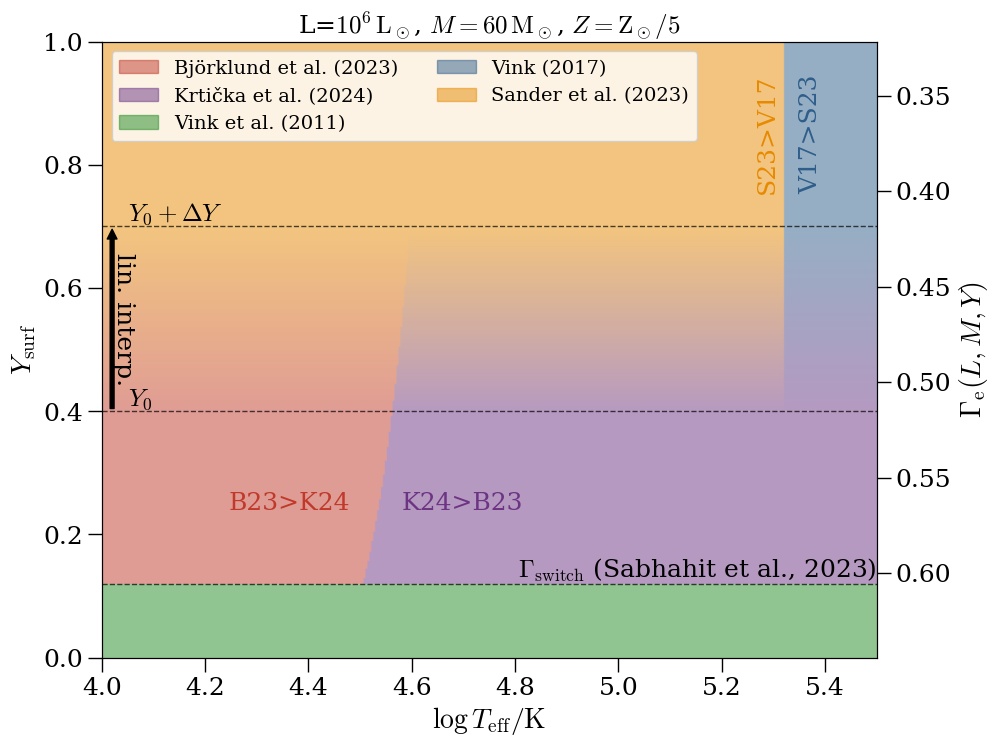

In [33]:
logteff_range = np.linspace(4, 5.5, 400)
y_range = np.linspace(0, 1, 400)
LT_mesh, Y_mesh = np.meshgrid(logteff_range, y_range)

regime_map = {
    'Vink (2017)': 0, 
    'Sander et al. (2023)': 1, 
    'Vink et al. (2011)': 2, 
    'Björklund et al. (2023)': 3, 
    'Krtička et al. (2024)': 4
}

regimes_to_blend = ["Sander et al. (2023)", "Vink (2017)"]

# Base colors
hex_colors = [
    '#2E5E8A', # Steel Blue (Vink 2017)
    '#E68A00', # Rich Amber (Sander 2023)
    '#228B22', # Forest Green (Vink 2011)
    '#C0392B', # Soft Crimson (Bjorklund 2023)
    '#6C3483'  # Muted Plum (Krticka 2024)
]
hex_colors_dict = dict(zip(regime_map.keys(), hex_colors))
rgb_colors = [np.array(mcolors.to_rgb(c)) for c in hex_colors]
rgb_colors_dict = dict(zip(regime_map.keys(), rgb_colors))

# Define transparency (alpha)
global_alpha = 0.5
# White background for blending
bg_color = np.array([1, 1, 1])

RGB_grid = np.zeros((len(y_range), len(logteff_range), 3))

for i in range(len(y_range)):
    y_val = y_range[i]
    for j in range(len(logteff_range)):
        teff_val = 10**logteff_range[j]
        x_val = 1 - y_val - Z
        
        name, alpha_blend, neighbor_name = which_wind(L, M, teff_val, Z, x_val)
        c_winner = rgb_colors[regime_map[name]]
        c_neighbor = rgb_colors[regime_map[neighbor_name]]
        
        if name in regimes_to_blend:
            if alpha_blend >= 1.0:
                raw_color = c_winner
            elif alpha_blend <= 0.0:
                raw_color = c_winner
            else:
                raw_color = c_winner * alpha_blend + c_neighbor * (1 - alpha_blend)
        else:
            raw_color = c_winner
        RGB_grid[i, j] = raw_color * global_alpha + bg_color * (1 - global_alpha)

# --- Plotting ---
fig, ax1 = plt.subplots(figsize=(10, 8))

# Plot the RGB grid
ax1.imshow(RGB_grid, extent=[4, 5.5, 0, 1], origin='lower', aspect='auto')

# Secondary axis for Gamma_e
ax2 = ax1.twinx()
gamma_at_y0 = edd_gamma(1 - 0 - Z, L, M)
gamma_at_y1 = edd_gamma(1 - 1 - Z, L, M)
ax2.set_ylim(gamma_at_y0, gamma_at_y1)
ax2.set_ylabel(r'$\Gamma_{\mathrm{e}}(L,M,Y)$')

# Main Axis Formatting
ax1.set_xlabel(r'$\log T_\mathrm{eff} / \mathrm{K}$')
ax1.set_ylabel(r'$Y_\mathrm{surf}$')

# Setting the title
ax1.set_title(f'L=$10^{{{int(np.log10(L))}}}\\,\\mathrm{{L}}_\\odot$, $M={M}\\,\\mathrm{{M}}_\\odot$, $Z=\\mathrm{{Z}}_\\odot/{Z_SUN/Z:.0f}$')

# Legend Configuration
legend_order = [
    'Björklund et al. (2023)', 
    'Krtička et al. (2024)', 
    'Vink et al. (2011)', 
    'Vink (2017)', 
    'Sander et al. (2023)'
]

patches = [
    plt.Rectangle((0,0), 1, 1, color=hex_colors[regime_map[lbl]], alpha=global_alpha, label=lbl) 
    for lbl in legend_order
]

ax1.legend(handles=patches, ncol=2, frameon=True, loc='upper left', bbox_to_anchor=(0, 1))

#ax1.grid(True, linestyle=':', alpha=0.3, color='black')
ax1.set_xlim(4, 5.5)
ax1.set_ylim(0, 1)

# Annotations 

annotation_small_fontsize = 18
annotation_large_fontsize = 18

ax1.hlines(y0, 4, 5.5, colors='black', linestyles='--', lw=1, alpha=0.7, zorder=3)
ax1.text(4.05, y0, '$Y_0$', va='bottom', ha='left', fontsize=annotation_small_fontsize, zorder=3)
ax1.hlines(y0 + dy, 4, 5.5, colors='black', linestyles='--', lw=1, alpha=0.7, zorder=3)
ax1.text(4.05, y0 + dy, '$Y_0 + \Delta Y$', va='bottom', ha='left', fontsize=annotation_small_fontsize, zorder=3)
ax2.hlines(sabhahit2023_switch_g(Z), 4, 5.5, colors='black', linestyles='--', lw=1, alpha=0.7, zorder=3)
ax2.text(5.5, sabhahit2023_switch_g(Z), '$\Gamma_\mathrm{switch}$ (Sabhahit et al., 2023)', va='bottom', ha='right', fontsize=annotation_large_fontsize, zorder=3)

x_ip_ann = 4.02
ax1.annotate(text='', xytext=(x_ip_ann, y0), xy=(x_ip_ann, y0+dy), arrowprops=dict(arrowstyle='simple', facecolor='black'), transform=ax1.transData)
ax1.text(x_ip_ann, 0.55, "lin. interp.", ha="left", va="center", fontsize=annotation_small_fontsize, rotation=-90)

ax1.text(4.48, 0.25, "B23>K24", ha="right", va="center", color=rgb_colors_dict['Björklund et al. (2023)'], fontsize=annotation_small_fontsize)
ax1.text(4.58, 0.25, "K24>B23", ha="left", va="center", color=rgb_colors_dict['Krtička et al. (2024)'], fontsize=annotation_small_fontsize)
ax1.text(5.31, 0.85, "S23>V17", ha="right", va="center", color=rgb_colors_dict['Sander et al. (2023)'], fontsize=annotation_small_fontsize, rotation=90)
ax1.text(5.35, 0.85, "V17>S23", ha="left", va="center", color=rgb_colors_dict['Vink (2017)'], fontsize=annotation_small_fontsize, rotation=90)

savefig(fig, 'wind_schematic_v2')

# Schematic wind plot